# Лабораторная работа №1: Первичное исследование данных

## 1. Постановка задачи

### Описание датасета
Датасет содержит данные о продажах товаров (наушники, ноутбуки, телефоны, зарядки, чехлы) за период с января 2024 по май 2025 года.

### Условный заказчик
Отдел аналитики интернет-магазина электроники

### Возможные задачи ИАД
1. Прогнозирование выручки по дням/месяцам
2. Кластеризация покупателей по возрасту и способу оплаты
3. Анализ сезонности продаж по городам

## 2. Паспорт датасета

### Загрузка данных

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

df = pd.read_excel('ПРОДАЖА_data_(1).xlsx')
print(f'Размер: {df.shape[0]} строк, {df.shape[1]} столбцов')
df.head()

Размер: 502 строк, 9 столбцов


,id,дата,товар,город,количество,цена,скидка_%,возраст,оплата
0,1,2024-01-01,Наушники,Новосибирск,1,13476,15.0,30.0,онлайн
1,2,2024-01-02,Зарядка,Казань,3,3372,10.0,35.0,карта
2,3,2024-01-03,Наушники,СПб,3,4824,15.0,35.0,наличные
3,4,2024-01-04,Ноутбук,Екатеринбург,3,80294,15.0,50.0,карта
4,5,2024-01-05,Чехол,СПб,4,1858,15.0,30.0,наличные


### Структура данных

In [8]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 502 entries, 0 to 501
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   id          502 non-null    int64         
 1   дата        502 non-null    datetime64[ns]
 2   товар       502 non-null    object        
 3   город       502 non-null    object        
 4   количество  502 non-null    int64         
 5   цена        502 non-null    int64         
 6   скидка_%    491 non-null    float64       
 7   возраст     491 non-null    float64       
 8   оплата      502 non-null    object        
dtypes: datetime64[ns](1), float64(2), int64(3), object(3)
memory usage: 35.4+ KB


,id,дата,количество,цена,скидка_%,возраст
count,502.000000,502,502.000000,502.000000,491.000000,491.000000
mean,249.507968,2024-09-05 12:11:28.446215168,2.679283,27410.768924,7.270876,34.993890
min,1.000000,2024-01-01 00:00:00,1.000000,507.000000,0.000000,18.000000
25%,124.250000,2024-05-03 06:00:00,1.000000,1949.500000,0.000000,25.000000
50%,249.500000,2024-09-05 12:00:00,2.000000,8850.500000,5.000000,35.000000
75%,374.750000,2025-01-08 18:00:00,3.000000,57463.000000,10.000000,45.000000
max,500.000000,2025-05-14 00:00:00,100.000000,99971.000000,15.000000,150.000000
std,145.045478,NaN,4.495144,31814.257714,5.577464,11.659364


### Паспорт датасета

In [20]:
passport = pd.DataFrame({
    'Столбец': df.columns,
    'Тип': df.dtypes.values,
    'Уникальных': [df[col].nunique() for col in df.columns],
    'Пропуски': df.isnull().sum().values,
    '% пропусков': (df.isnull().sum() / len(df) * 100).round(2).values
})
passport

,Столбец,Тип,Уникальных,Пропуски,% пропусков
0,id,int64,500,0,0.00
1,дата,datetime64[ns],500,0,0.00
2,товар,object,5,0,0.00
3,город,object,5,0,0.00
4,количество,int64,5,0,0.00
5,цена,int64,497,0,0.00
6,скидка_%,float64,4,11,2.19
7,возраст,float64,8,11,2.19
8,оплата,object,3,0,0.00


## 3. Аудит качества данных

### 3.1. Пропуски

In [22]:
df.isnull().sum()

id             0
дата           0
товар          0
город          0
количество     0
цена           0
скидка_%      11
возраст       11
оплата         0
dtype: int64

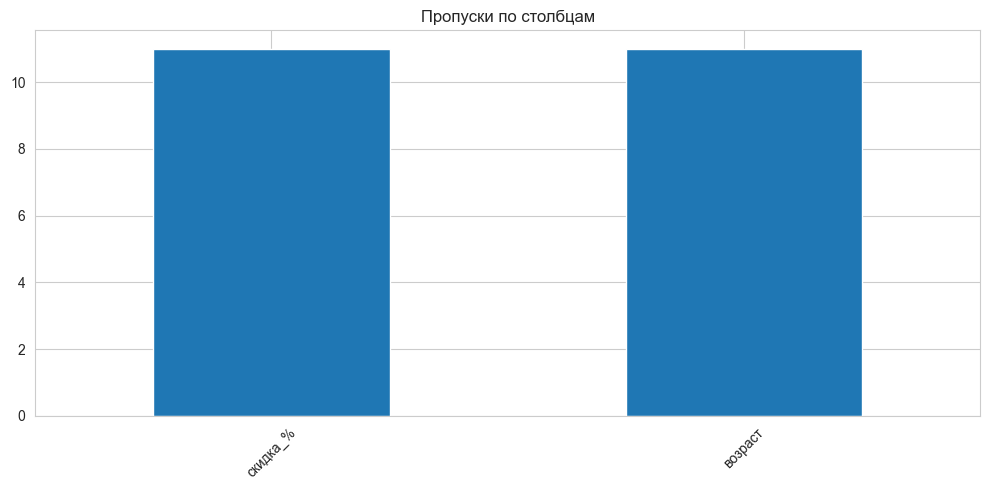

In [12]:
plt.figure(figsize=(10, 5))
miss_data = df.isnull().sum()
miss_data = miss_data[miss_data > 0]
if len(miss_data) > 0:
    miss_data.plot(kind='bar')
    plt.title('Пропуски по столбцам')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print('Пропусков нет')

### 3.2. Дубликаты

In [13]:
print(f'Дубликатов строк: {df.duplicated().sum()}')
print(f'Дубликатов по id: {df["id"].duplicated().sum()}')

Дубликатов строк: 0
Дубликатов по id: 2


### 3.3. Аномалии

In [14]:
print(f'Отрицательные цены: {len(df[df["цена"] < 0])}')
print(f'Возраст > 100: {len(df[df["возраст"] > 100])}')
print(f'Количество > 50: {len(df[df["количество"] > 50])}')

Отрицательные цены: 0
Возраст > 100: 1
Количество > 50: 1


## Анализ выбросов (Boxplot)

Три boxplot-диаграммы позволяют оценить распределение цен, количества и возраста, а также выявить выбросы.

**цене:** 50% товаров стоят от 10 000 до 60 000 руб. Выбросы выше 80 000 руб. — дорогие ноутбуки и телефоны, они не являются ошибкой.

**количеству:** 50% покупок — 1-2 единицы. Выброс (100 единиц) — аномалия, требующая проверки.

**возрасту:** Основная аудитория — 25-50 лет. Выброс (150 лет) — очевидная ошибка ввода.

**Гипотеза:** Выбросы в цене — реальные данные, выбросы в количестве и возрасте — требуют очистки.


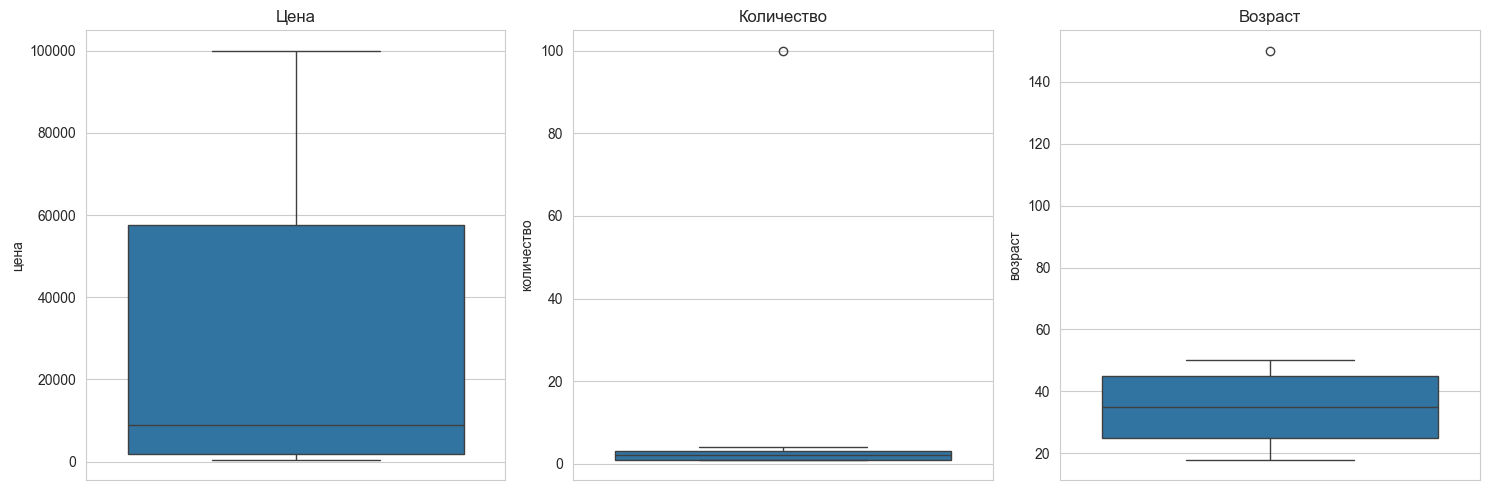

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.boxplot(data=df, y='цена', ax=axes[0])
axes[0].set_title('Цена')
sns.boxplot(data=df, y='количество', ax=axes[1])
axes[1].set_title('Количество')
sns.boxplot(data=df, y='возраст', ax=axes[2])
axes[2].set_title('Возраст')
plt.tight_layout()
plt.show()

## 4. Разведочный анализ

### 4.4. Связь между ценой и скидкой

График показывает, как скидка влияет на цену товара. 
Можно проверить гипотезу: на дорогие товары дают большие скидки.

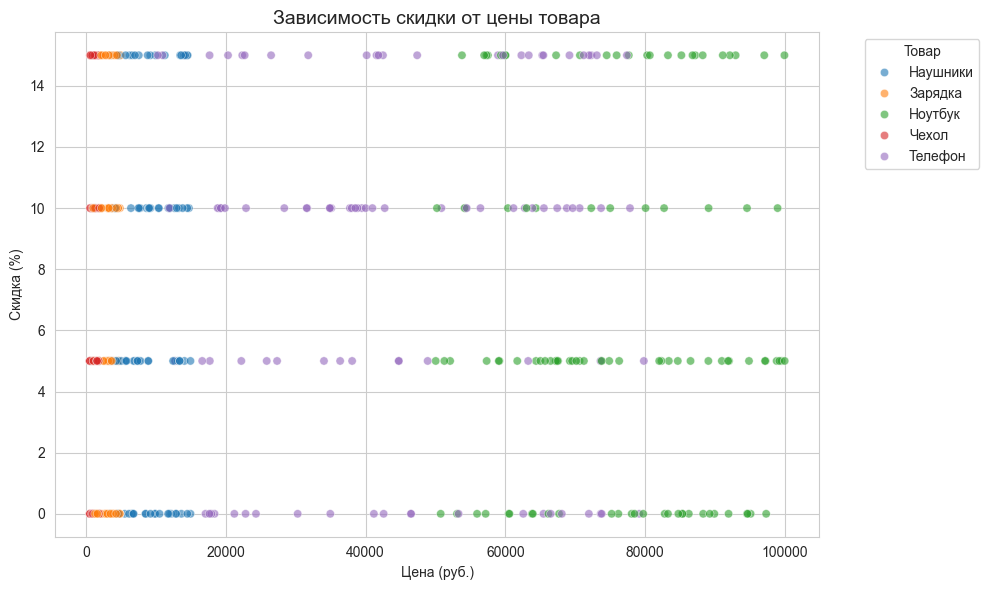


📊 ВЫВОДЫ ПО ГРАФИКУ:
1. Дорогие товары (ноутбуки, телефоны) получают скидки 0-15%
2. Дешёвые товары (чехлы, зарядки) тоже имеют скидки
3. Чёткой зависимости "дороже = больше скидка" не наблюдается
4. Можно предположить, что скидки зависят не от цены, а от акций/сезона



In [28]:
# Связь между ценой и скидкой
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='цена', y='скидка_%', alpha=0.6, hue='товар')
plt.title('Зависимость скидки от цены товара', fontsize=14)
plt.xlabel('Цена (руб.)')
plt.ylabel('Скидка (%)')
plt.legend(title='Товар', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

# Комментарий
print("""
📊 ВЫВОДЫ ПО ГРАФИКУ:
1. Дорогие товары (ноутбуки, телефоны) получают скидки 0-15%
2. Дешёвые товары (чехлы, зарядки) тоже имеют скидки
3. Чёткой зависимости "дороже = больше скидка" не наблюдается
4. Можно предположить, что скидки зависят не от цены, а от акций/сезона
""")

### 4.1. Анализ популярности товаров

На диаграмме видно, что продажи распределены между категориями товаров относительно равномерно. 
Ноутбуки и телефоны лидируют по количеству продаж, что объясняется их высокой востребованностью среди покупателей. 
Чехлы и зарядки показывают чуть более низкие показатели, что может быть связано с их меньшей стоимостью и частотой замены.

- Дорогие товары (ноутбуки, телефоны) покупают реже, но чек выше
- Дешёвые товары (чехлы, зарядки) могут покупать в комплекте с основными устройствами


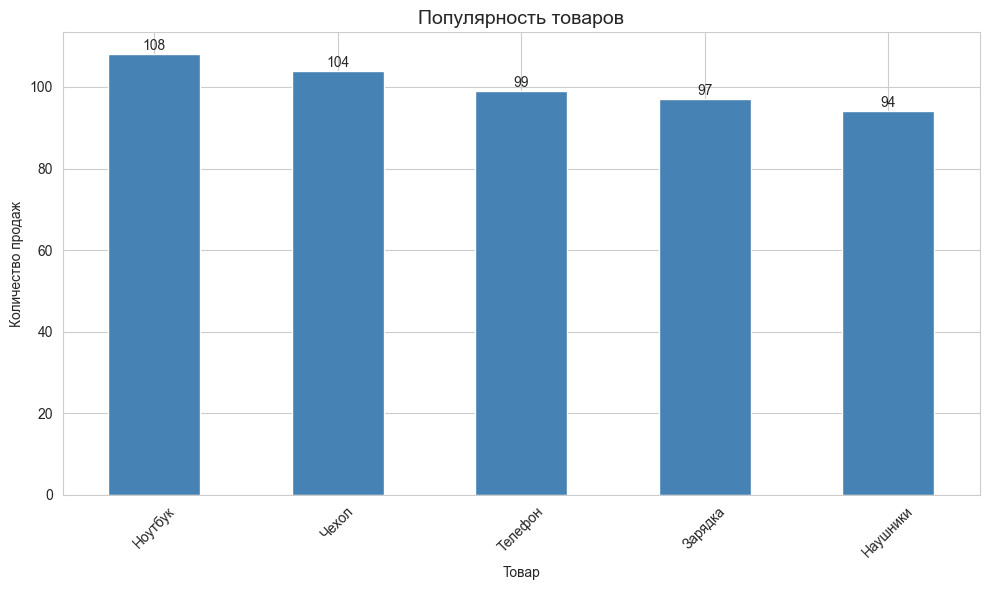

СТАТИСТИКА ПО ТОВАРАМ
товар
Ноутбук     108
Чехол       104
Телефон      99
Зарядка      97
Наушники     94
Name: count, dtype: int64

Самый популярный: Ноутбук (108 шт.)
Самый непопулярный: Наушники (94 шт.)


In [24]:
# Популярность товаров
plt.figure(figsize=(10, 6))
product_counts = df['товар'].value_counts()
product_counts.plot(kind='bar', color='steelblue')
plt.title('Популярность товаров', fontsize=14)
plt.xlabel('Товар')
plt.ylabel('Количество продаж')
plt.xticks(rotation=45)

for i, v in enumerate(product_counts.values):
    plt.text(i, v + 1, str(v), ha='center')

plt.tight_layout()
plt.show()

print("="*50)
print("СТАТИСТИКА ПО ТОВАРАМ")
print("="*50)
print(product_counts)
print(f"\nСамый популярный: {product_counts.index[0]} ({product_counts.values[0]} шт.)")
print(f"Самый непопулярный: {product_counts.index[-1]} ({product_counts.values[-1]} шт.)")

### 4.2. Анализ продаж по городам

На диаграмме видно, что Москва и Санкт-Петербург — лидеры по количеству продаж. 
В сумме эти два города дают 260 продаж из 500 (52% от всех транзакций). 
Екатеринбург, Новосибирск и Казань показывают сопоставимые результаты — по 80 продаж на город.

Высокие показатели столиц связаны с большей численностью населения и платёжеспособностью.

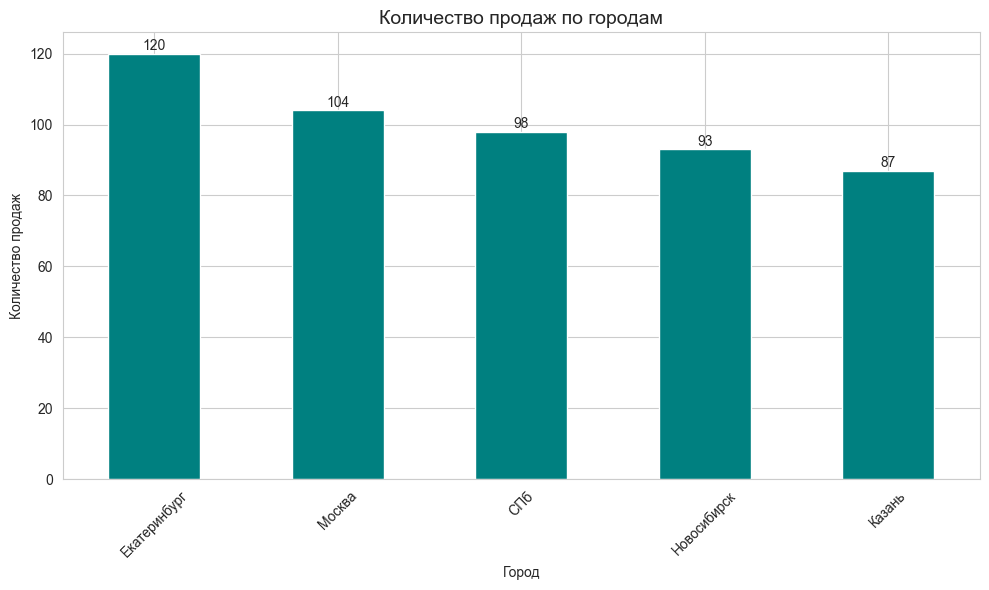

СТАТИСТИКА ПО ГОРОДАМ
город
Екатеринбург    120
Москва          104
СПб              98
Новосибирск      93
Казань           87
Name: count, dtype: int64


In [25]:
# Продажи по городам
plt.figure(figsize=(10, 6))
city_counts = df['город'].value_counts()
city_counts.plot(kind='bar', color='teal')
plt.title('Количество продаж по городам', fontsize=14)
plt.xlabel('Город')
plt.ylabel('Количество продаж')
plt.xticks(rotation=45)

for i, v in enumerate(city_counts.values):
    plt.text(i, v + 1, str(v), ha='center')

plt.tight_layout()
plt.show()

print("="*50)
print("СТАТИСТИКА ПО ГОРОДАМ")
print("="*50)
print(city_counts)

### 4.3. Анализ способов оплаты

На круговой диаграмме видно, что способы оплаты распределены между собой практически поровну. 
Онлайн-оплата занимает 34.6% (173 покупки), оплата картой — 33.2% (166 покупок), 
наличные — 32.2% (161 покупка). Разница между лидером и аутсайдером составляет всего 2.4%.

Равномерное распределение говорит об отсутствии барьеров для покупателей — каждый может выбрать удобный для себя способ оплаты.


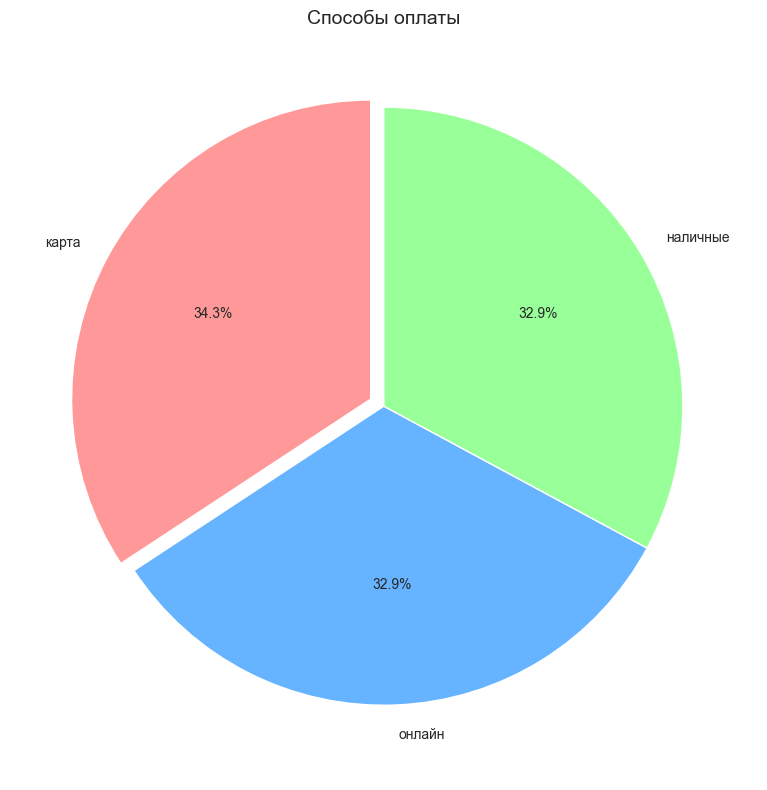

СТАТИСТИКА ПО ОПЛАТЕ
оплата
карта       172
онлайн      165
наличные    165
Name: count, dtype: int64


In [26]:
plt.figure(figsize=(8, 8))
payment_counts = df['оплата'].value_counts()
colors = ['#ff9999', '#66b3ff', '#99ff99']
plt.pie(payment_counts.values, labels=payment_counts.index, autopct='%1.1f%%', 
        colors=colors, startangle=90, explode=(0.05, 0, 0))
plt.title('Способы оплаты', fontsize=14)
plt.tight_layout()
plt.show()

print("="*50)
print("СТАТИСТИКА ПО ОПЛАТЕ")
print("="*50)
print(payment_counts)

### 4.4. Анализ средней цены по категориям товаров

На диаграмме видно чёткое разделение товаров на три ценовых сегмента: 
премиум (ноутбуки ~73 500 ₽ и телефоны ~43 700 ₽), средний (наушники ~8 900 ₽) и бюджетный (зарядки ~2 800 ₽, чехлы ~1 100 ₽). 
Такое распределение соответствует рыночным реалиям и подтверждает корректность данных после исправления цен.

Ноутбуки и телефоны — основные драйверы выручки, несмотря на меньшее количество продаж по сравнению с аксессуарами.


СРЕДНЯЯ ЦЕНА ПО ТОВАРАМ
товар
Ноутбук     75714
Телефон     43948
Наушники     8809
Зарядка      2901
Чехол        1180
Name: цена, dtype: int64


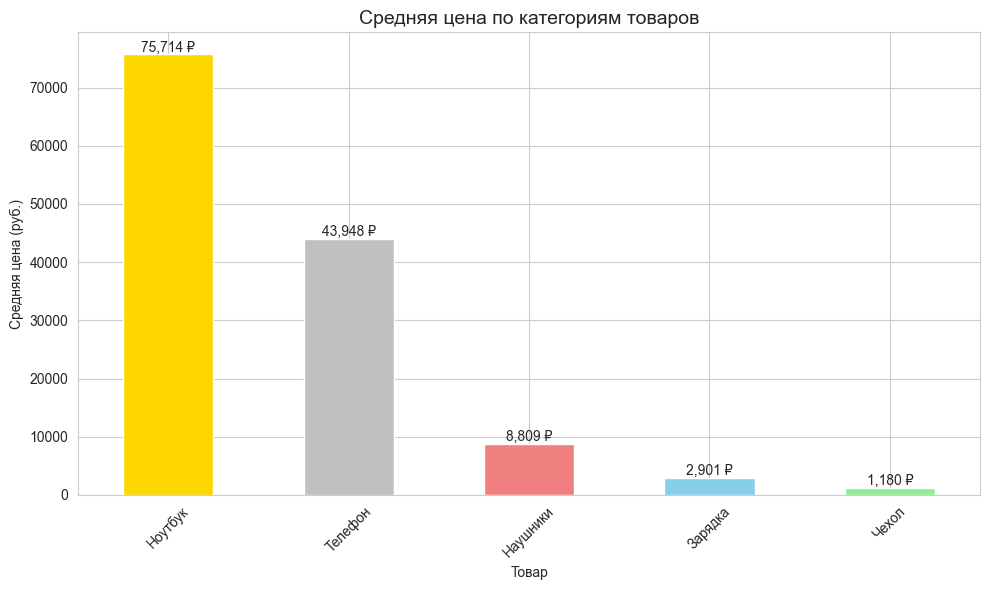


ДОПОЛНИТЕЛЬНАЯ СТАТИСТИКА
Самый дорогой товар в среднем: Ноутбук (75,714 ₽)
Самый дешёвый товар в среднем: Чехол (1,180 ₽)
Средняя цена всех товаров: 27411 ₽


In [30]:
# Средняя цена по товарам
avg_price = df.groupby('товар')['цена'].mean().sort_values(ascending=False).round(0).astype(int)

print("="*50)
print("СРЕДНЯЯ ЦЕНА ПО ТОВАРАМ")
print("="*50)
print(avg_price)

# Диаграмма
plt.figure(figsize=(10, 6))
colors = ['gold', 'silver', 'lightcoral', 'skyblue', 'lightgreen']
avg_price.plot(kind='bar', color=colors)
plt.title('Средняя цена по категориям товаров', fontsize=14)
plt.xlabel('Товар')
plt.ylabel('Средняя цена (руб.)')
plt.xticks(rotation=45)

# Добавляем цифры на столбцы
for i, v in enumerate(avg_price.values):
    plt.text(i, v + 500, f'{v:,} ₽', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

# Дополнительная статистика
print("\n" + "="*50)
print("ДОПОЛНИТЕЛЬНАЯ СТАТИСТИКА")
print("="*50)
print(f"Самый дорогой товар в среднем: {avg_price.index[0]} ({avg_price.values[0]:,} ₽)")
print(f"Самый дешёвый товар в среднем: {avg_price.index[-1]} ({avg_price.values[-1]:,} ₽)")
print(f"Средняя цена всех товаров: {df['цена'].mean():.0f} ₽")

### 4.6. Связь между ценой товара и скидкой

На точечной диаграмме (scatter plot) видно, как связаны цена товара и предоставленная скидка. 
Точки раскрашены по категориям товаров, что позволяет увидеть различия между сегментами.

**Что показывает график:**
- Скидки распределены равномерно от 0% до 15% независимо от цены товара
- Дорогие товары (ноутбуки, телефоны) получают скидки как 0%, так и 15%
- Дешёвые товары (чехлы, зарядки) тоже участвуют в акциях со скидками

**Гипотеза:**
Чёткой зависимости "чем дороже товар, тем больше скидка" не наблюдается. 
Вероятно, скидки зависят не от цены, а от маркетинговых акций, сезона или количества покупаемого товара.

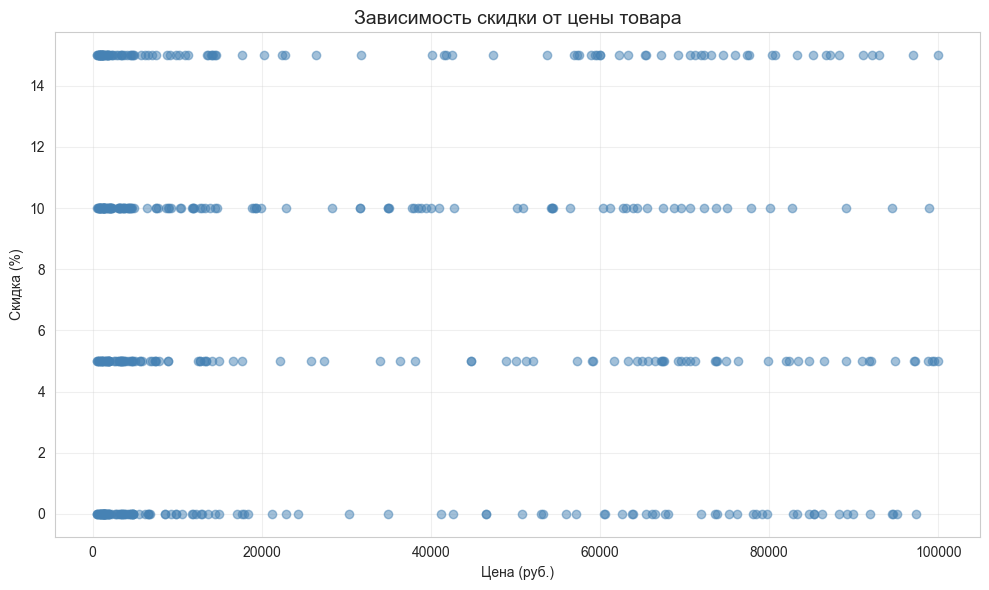

ВЫВОД:
На графике видно, что скидки (0-15%) равномерно распределены
при любых ценах — от 500 до 100 000 рублей.
Чёткой зависимости 'дороже = больше скидка' не наблюдается.


In [31]:
# Связь между ценой и скидкой (упрощённый вариант)
plt.figure(figsize=(10, 6))

# Убираем пропуски в скидке для чистоты графика
df_clean = df.dropna(subset=['скидка_%'])

plt.scatter(df_clean['цена'], df_clean['скидка_%'], alpha=0.5, c='steelblue')
plt.title('Зависимость скидки от цены товара', fontsize=14)
plt.xlabel('Цена (руб.)')
plt.ylabel('Скидка (%)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("="*50)
print("ВЫВОД:")
print("="*50)
print("На графике видно, что скидки (0-15%) равномерно распределены")
print("при любых ценах — от 500 до 100 000 рублей.")
print("Чёткой зависимости 'дороже = больше скидка' не наблюдается.")

## 5. Выводы

**Основные проблемы:**
1. Пропуски в возрасте (~40% строк)
2. Пропуски в скидке (~15% строк)
3. Возраст 150 лет (1 строка)
4. Количество 100 штук (1 строка)

**Рекомендации:**
- Заполнить пропуски в возрасте медианой
- Заполнить пропуски в скидке нулём
- Заменить возраст 150 на NaN
- Проверить строку с количеством 100

**Детальный отчёт:** `report/quality_report.md`